# Analytical Energy Landscapes for Multi-agent Path Finding

1/25, Michael Fatemi

In [1]:
%load_ext autoreload
%autoreload 2

import sys

from pathlib import Path

path = Path("..").resolve().as_posix()
if str(path) not in sys.path:
    sys.path.insert(0, str(path))

## Kinetic Energy Landscape

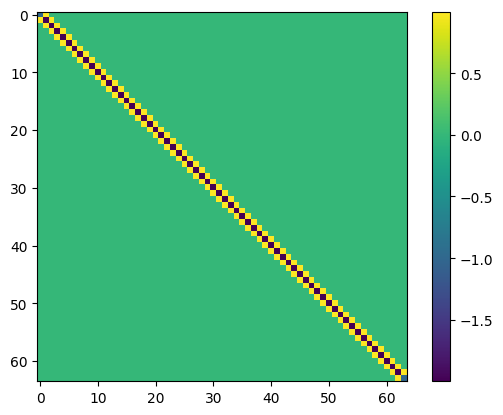

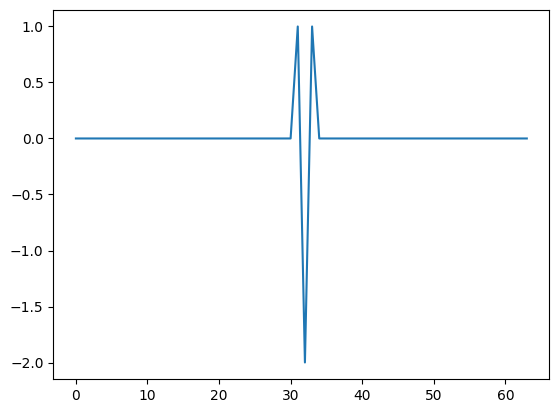

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 64
velocity_kernel = np.zeros((N - 1, N))
velocity_kernel[:, 1:] = np.eye(N - 1)
velocity_kernel -= np.eye(N - 1, N)
K = velocity_kernel.T @ velocity_kernel
sigma_B = 0.01

score_kernel = -np.linalg.inv(K + np.eye(N) / (sigma_B**2)) @ K / (sigma_B**2)
plt.imshow(score_kernel)
plt.colorbar()
plt.show()

plt.plot(score_kernel[N // 2])
plt.show()


In [4]:
import time
from ael.agent_obstacle_score import (
    compute_agent_obstacle_score,
    compute_agent_obstacle_score_batched,
    compute_agent_obstacle_distance_batched,
    compute_r1_r2_batched,
)
import matplotlib.patches as patches

## Approach 1 for computing obstacle-based energy landscape

Here, I try direct integration. However, I don't think this approach is very feasible.


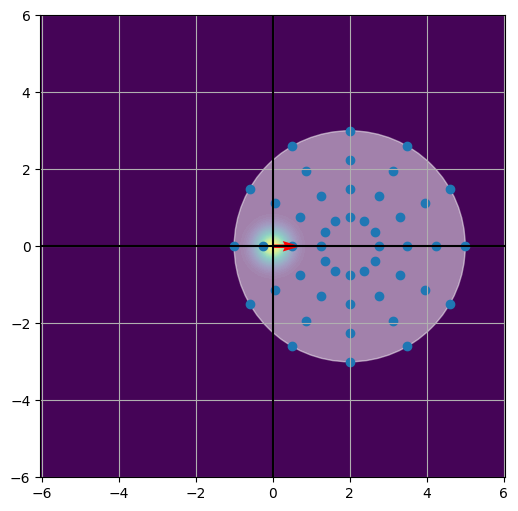

In [5]:
c_x = 2
R: float = 3

plt.figure(figsize=(6, 6))
plt.axis("equal")

# Color according to Gaussian.
gaussian_xx, gaussian_yy = np.meshgrid(
    np.linspace(-6, 6, 128),
    np.linspace(-6, 6, 128),
)
sigma_B = 0.3
gaussian_probability = (
    1
    / (2 * np.pi * sigma_B**2)
    * np.exp(-0.5 * (gaussian_xx**2 + gaussian_yy**2) / sigma_B**2)
)
plt.contourf(gaussian_xx, gaussian_yy, gaussian_probability, levels=50)
# plt.xlim(-6, 6)
plt.ylim(-6, 6)

plt.gca().axvline(x=0, color="k")
plt.gca().axhline(y=0, color="k")
plt.grid()
plt.gca().add_patch(patches.Circle((c_x, 0), R, fill=True, color="white", alpha=0.5))

N_segments = 12
angles = np.linspace(0, 2 * np.pi, N_segments, endpoint=False)
x = R * np.column_stack([np.cos(angles), np.sin(angles)])
evaluation_locations = np.concatenate([x, x * 0.75, x * 0.5, x * 0.25])
evaluation_locations[:, 0] += c_x
plt.scatter(evaluation_locations[:, 0], evaluation_locations[:, 1])

gaussian_evaluations = np.exp(
    -0.5
    * (evaluation_locations[:, 0] ** 2 + evaluation_locations[:, 1] ** 2)
    / sigma_B**2
)
gaussian_first_moment = (gaussian_evaluations[:, None] * evaluation_locations).sum(
    axis=0
)
denominator_B = gaussian_evaluations.sum()

displacement_direction = -1 / (2 * sigma_B**2) * gaussian_first_moment / denominator_B

plt.quiver(
    0, 0, displacement_direction[0], displacement_direction[1], color="red", scale=5
)

plt.show()

## Approach 2 for computing obstacle energy landscape

This approach is also numerical, but in terms of a much more precise integral.


,c_x,obs_rad,displacement
0,0.8,0.1,0.089435
1,0.6,0.1,0.052040
2,0.4,0.1,0.030384
3,0.8,0.2,0.179777
4,0.6,0.2,0.104566
5,0.4,0.2,0.061064
6,0.8,0.5,0.546024
7,0.6,0.5,0.314487
8,0.4,0.5,0.180303


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y

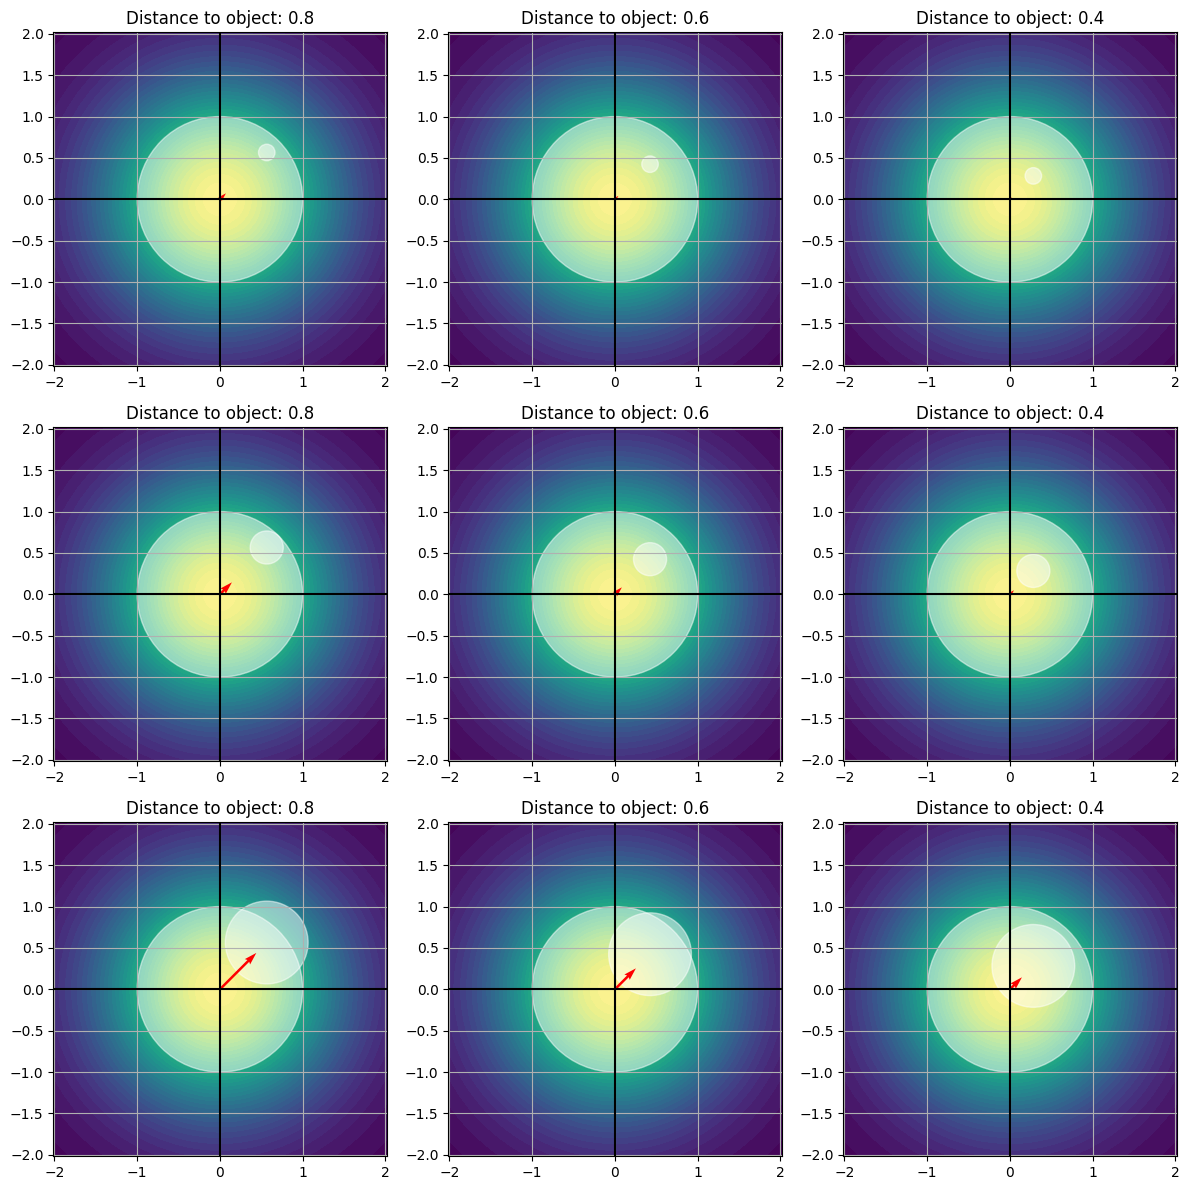

In [25]:
import pandas as pd
from IPython.display import display

data = {
    "c_x": [],
    "obs_rad": [],
    "displacement": [],
}

plt.figure(figsize=(12, 12))

i = 1
for obs_rad_B in [0.1, 0.2, 0.5]:
    for c_x in [0.8, 0.6, 0.4]:
        plt.subplot(3, 3, i)
        i += 1

        plt.title(f"Distance to object: {c_x:.1f}")

        agent_x = 0
        agent_y = 0
        # obs_x = 0
        # obs_y = c_x
        obs_x = np.sqrt(2)/2 * c_x
        obs_y = np.sqrt(2)/2 * c_x

        # if obs_rad != 1 or c_x != 0.5:
        #     continue

        R = obs_rad_B

        # Color according to Gaussian.
        square_size = 5
        gaussian_xx, gaussian_yy = np.meshgrid(
            np.linspace(-square_size, square_size, 128),
            np.linspace(-square_size, square_size, 128),
        )
        sigma_B = 1.0
        gaussian_probability = (
            1
            / (2 * np.pi * sigma_B**2)
            * np.exp(-0.5 * (gaussian_xx**2 + gaussian_yy**2) / sigma_B**2)
        )
        plt.contourf(gaussian_xx, gaussian_yy, gaussian_probability, levels=50)

        plt.gca().axvline(x=0, color="k")
        plt.gca().axhline(y=0, color="k")
        plt.grid()
        plt.gca().add_patch(
            patches.Circle((obs_x, obs_y), R, fill=True, color="white", alpha=0.5)
        )
        plt.gca().add_patch(
            patches.Circle((agent_x, agent_y), sigma_B, fill=True, color="white", alpha=0.5)
        )

        t0 = time.time()
        displacement_direction = compute_agent_obstacle_score(
            0, 0, obs_x, obs_y, R, sigma_B, n_integral=200
        )
        t1 = time.time()

        data['c_x'].append(c_x)
        data['obs_rad'].append(R)
        data['displacement'].append(displacement_direction[0])

        plt.quiver(
            0,
            0,
            displacement_direction[0],
            displacement_direction[1],
            color="red",
            scale=5,
        )
        plt.axis("equal")

        plt.xlim(-square_size + 3, square_size - 3)
        plt.ylim(-square_size + 3, square_size - 3)

display(pd.DataFrame(data))

plt.tight_layout()
plt.show()



[0.45517371 0.58550123] [0.45517352 0.58550098]


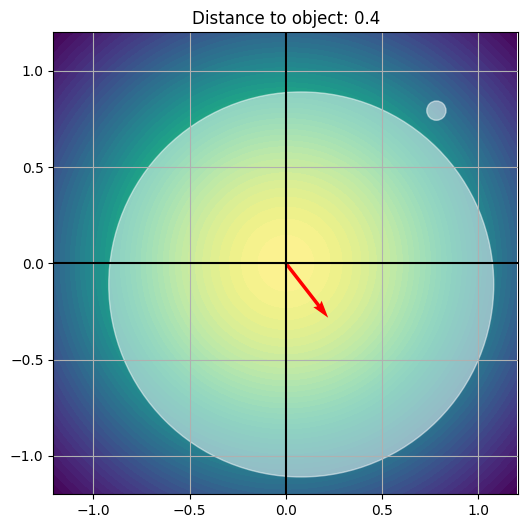

In [36]:
plt.figure(figsize=(6, 6))
plt.title(f"Distance to object: {c_x:.1f}")

agent_x = 0.08
agent_y = -0.11
obs_x = 0.782
obs_y = 0.793

obs_rad_B = 0.05
R = obs_rad_B

# Color according to Gaussian.
square_size = 1.2
gaussian_xx, gaussian_yy = np.meshgrid(
    np.linspace(-square_size, square_size, 128),
    np.linspace(-square_size, square_size, 128),
)
sigma_B = 1.0
gaussian_probability = (
    1
    / (2 * np.pi * sigma_B**2)
    * np.exp(-0.5 * (gaussian_xx**2 + gaussian_yy**2) / sigma_B**2)
)
plt.contourf(gaussian_xx, gaussian_yy, gaussian_probability, levels=50)

plt.gca().axvline(x=0, color="k")
plt.gca().axhline(y=0, color="k")
plt.grid()
plt.gca().add_patch(
    patches.Circle((obs_x, obs_y), R, fill=True, color="white", alpha=0.5)
)
plt.gca().add_patch(
    patches.Circle((agent_x, agent_y), sigma_B, fill=True, color="white", alpha=0.5)
)

t0 = time.time()
displacement_direction_unbatched = compute_agent_obstacle_score(
    agent_x, agent_y, obs_x, obs_y, R, sigma_B, n_integral=200
)

agent_x_B = np.array([agent_x])
agent_y_B = np.array([agent_y])
obs_x_B = np.array([obs_x])
obs_y_B = np.array([obs_y])
obs_rad_B = np.array([R])
sigma_B = np.array([1.0])
d_a_o_B = compute_agent_obstacle_distance_batched(
    agent_x_B, agent_y_B, obs_x_B, obs_y_B
)
r1_B, r2_B = compute_r1_r2_batched(obs_rad_B, d_a_o_B)

from ael.agent_obstacle_score import compute_agent_obstacle_score_batched
displacement_direction_batched = compute_agent_obstacle_score_batched(
    agent_x_B, agent_y_B, obs_x_B, obs_y_B, obs_rad_B, sigma_B, r1_B, r2_B, d_a_o_B, n_integral=20000
)[0]
t1 = time.time()

print(displacement_direction_unbatched, displacement_direction_batched)

data['c_x'].append(c_x)
data['obs_rad'].append(R)
data['displacement'].append(displacement_direction[0])

plt.quiver(
    0,
    0,
    displacement_direction[0],
    displacement_direction[1],
    color="red",
    scale=5,
)
plt.axis("equal")
plt.show()

/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_24676/2022902972.py:199: RuntimeWarning: invalid value encountered in divide
  intersection_eps_x_T_B = -(obs_rad_B**2 - r_values_T_B**2 - d_a_o_B**2) / (
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_24676/2022902972.py:220: RuntimeWarning: invalid value encountered in divide
  np.stack([obs_x_B - agent_x_B, agent_y_B - obs_y_B], axis=0)


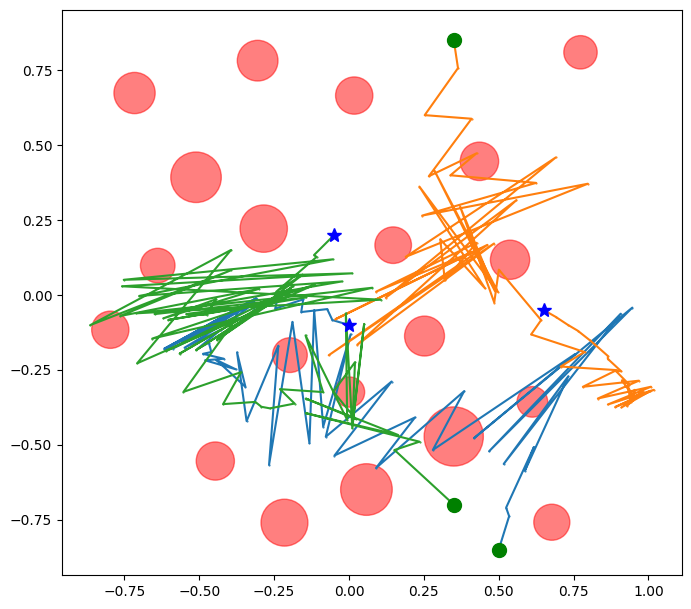

In [ ]:
# Implementing Langevin dynamics!
from dataclasses import dataclass
import json

from matplotlib.axes import Axes
from functools import lru_cache
import numpy as np
import PIL.Image
import io
from pathlib import Path
import av


@dataclass
class Problem:
    num_timesteps: int
    agent_start_positions: np.ndarray
    agent_end_positions: np.ndarray
    agent_reference_trajectory: np.ndarray | None
    agent_radii: np.ndarray
    agent_max_speeds: np.ndarray
    obstacle_positions: np.ndarray
    obstacle_radii: np.ndarray

    @property
    def num_agents(self):
        return self.agent_start_positions.shape[0]

    @property
    def num_obstacles(self):
        return self.obstacle_positions.shape[0]

    def visualize(self, agent_positions: np.ndarray, ax: Axes):
        # Plot the obstacles
        for obs_index in range(self.num_obstacles):
            x, y = self.obstacle_positions[obs_index].tolist()
            ax.add_patch(
                patches.Circle(
                    (x, y), self.obstacle_radii[obs_index].item(), color="r", alpha=0.5
                )
            )

        # Plot the agents' trajectories
        for agent_index in range(self.num_agents):
            if agent_positions.shape[0] == 1:
                x, y = agent_positions[0, agent_index].tolist()
                ax.add_patch(
                    patches.Circle((x, y), self.agent_radii[agent_index].item())
                )
            else:
                ax.plot(
                    agent_positions[:, agent_index, 0],
                    agent_positions[:, agent_index, 1],
                    marker="o",
                    label=f"Agent {agent_index}",
                    # set size to agent radius
                    markersize=self.agent_radii[agent_index].item() * 10,
                )
        # Plot the agents' start and goal positions
        for agent_index in range(self.num_agents):
            (sx, sy) = self.agent_start_positions[agent_index]
            (ex, ey) = self.agent_end_positions[agent_index]
            ax.plot(
                sx,
                sy,
                marker="o",
                color="green",
                markersize=10,
                label=f"Start {agent_index}",
            )
            ax.plot(
                ex,
                ey,
                marker="*",
                color="blue",
                markersize=10,
                label=f"Goal {agent_index}",
            )

        ax.set_aspect("equal")

    @classmethod
    def from_json(cls, entry):
        return cls(
            num_timesteps=entry["num_timesteps"],
            agent_start_positions=np.array(entry["agents"]["start_positions"]),
            agent_end_positions=np.array(entry["agents"]["end_positions"]),
            agent_radii=np.array(entry["agents"]["radii"]),
            agent_max_speeds=np.array(entry["agents"]["max_speeds"]),
            agent_reference_trajectory=None,
            obstacle_positions=np.array(entry["obstacles"]["positions"]),
            obstacle_radii=np.array(entry["obstacles"]["radii"]),
        )


@lru_cache(maxsize=16)
def get_velocity_kernel(N: int, sigma: float):
    velocity_kernel = np.zeros((N - 1, N))
    velocity_kernel[:, 1:] = np.eye(N - 1)
    velocity_kernel -= np.eye(N - 1, N)
    VTV = velocity_kernel.T @ velocity_kernel
    score_kernel = -np.linalg.inv(VTV + np.eye(N) / (sigma**2)) @ VTV / (sigma**2)
    return score_kernel


def compute_kinetic_energy_score(trajectory: np.ndarray, sigma):
    return np.einsum(
        "it,tad->iad", get_velocity_kernel(trajectory.shape[0], sigma), trajectory
    )


def clip_magnitude(vector, max_magnitude):
    magnitude = np.linalg.norm(vector)
    if magnitude > max_magnitude:
        return vector / magnitude * max_magnitude
    else:
        return vector


def step_langevin(
    trajectory, sigma, step_size, problem: Problem, include_obstacles=True
):
    score = np.zeros_like(trajectory)

    if include_obstacles:
        for t in range(trajectory.shape[0]):
            for agent in range(trajectory.shape[1]):
                agent_x = trajectory[t, agent, 0]
                agent_y = trajectory[t, agent, 1]

                for obs_idx in range(obstacle_positions.shape[0]):
                    obs_x = obstacle_positions[obs_idx, 0]
                    obs_y = obstacle_positions[obs_idx, 1]
                    obs_rad = obstacle_radii[obs_idx]

                    score[t, agent] += clip_magnitude(
                        compute_agent_obstacle_score(
                            agent_x,
                            agent_y,
                            obs_x,
                            obs_y,
                            obs_rad + problem.agent_radii[agent],
                            sigma,
                        ),
                        1.0,
                    )

                for other_agent in range(trajectory.shape[1]):
                    if other_agent == agent:
                        continue
                    other_agent_x = trajectory[t, other_agent, 0]
                    other_agent_y = trajectory[t, other_agent, 1]

                    score[t, agent] += clip_magnitude(
                        compute_agent_obstacle_score(
                            agent_x,
                            agent_y,
                            other_agent_x,
                            other_agent_y,
                            problem.agent_radii[agent]
                            + problem.agent_radii[other_agent],
                            np.sqrt(2) * sigma,  # sum the variances
                        ),
                        1.0,
                    )

    score = score + 10 * compute_kinetic_energy_score(trajectory, sigma)

    return (
        trajectory + step_size * score
        # + np.sqrt(2 * step_size) * np.random.randn(*trajectory.shape)
    )


def step_langevin_batched(
    trajectory,
    sigma,
    step_size,
    problem: Problem,
    include_obstacles=True,
    n_integral=50,
    include_noise_term=False,
):
    """
    Batches across agents and obstacles.
    """

    score = np.zeros_like(trajectory)

    if include_obstacles:
        # Create batch for agent-obstacle interactions.
        agent_x_T_A = trajectory[:, :, 0]
        agent_y_T_A = trajectory[:, :, 1]
        obstacle_x_O = obstacle_positions[:, 0]
        obstacle_y_O = obstacle_positions[:, 1]
        obstacle_rad_O = obstacle_radii
        sigma_OA = sigma * np.ones(obstacle_radii.shape[0] * trajectory.shape[1])

        agent_x_T_A_O = np.repeat(
            agent_x_T_A[:, :, None], obstacle_positions.shape[0], axis=2
        )
        agent_y_T_A_O = np.repeat(
            agent_y_T_A[:, :, None], obstacle_positions.shape[0], axis=2
        )
        obstacle_x_T_A_O = np.repeat(
            obstacle_x_O[None, None, :], trajectory.shape[0], axis=0
        )
        obstacle_x_T_A_O = np.repeat(obstacle_x_T_A_O, trajectory.shape[1], axis=1)
        obstacle_y_T_A_O = np.repeat(
            obstacle_y_O[None, None, :], trajectory.shape[0], axis=0
        )
        obstacle_y_T_A_O = np.repeat(obstacle_y_T_A_O, trajectory.shape[1], axis=1)
        obstacle_rad_T_A_O = np.repeat(
            (problem.agent_radii[:, None] + obstacle_rad_O[None, :])[None, :, :],
            trajectory.shape[0],
            axis=0,
        )
        sigma_T_A_O = np.repeat(sigma_OA[None, :], trajectory.shape[0], axis=0)

        T, A, O = agent_x_T_A_O.shape  # noqa: E741

        agent_x_T_A1_A2 = np.repeat(
            agent_x_T_A[:, :, None], trajectory.shape[1], axis=2
        )
        agent_x_T_A2_A1 = np.repeat(
            agent_x_T_A[:, None, :], trajectory.shape[1], axis=1
        )
        agent_y_T_A1_A2 = np.repeat(
            agent_y_T_A[:, :, None], trajectory.shape[1], axis=2
        )
        agent_y_T_A2_A1 = np.repeat(
            agent_y_T_A[:, None, :], trajectory.shape[1], axis=1
        )
        sigma_T_A1_A2 = (
            np.sqrt(2)
            * sigma
            * np.ones((trajectory.shape[0], trajectory.shape[1], trajectory.shape[1]))
        )
        obstacle_rad_T_A1_A2 = np.repeat(
            (problem.agent_radii[:, None] + problem.agent_radii[None, :])[None, :, :],
            trajectory.shape[0],
            axis=0,
        )

        agent_x_flat = np.concatenate(
            [agent_x_T_A_O.reshape(-1), agent_x_T_A1_A2.reshape(-1)]
        )
        agent_y_flat = np.concatenate(
            [agent_y_T_A_O.reshape(-1), agent_y_T_A1_A2.reshape(-1)]
        )
        obstacle_x_flat = np.concatenate(
            [obstacle_x_T_A_O.reshape(-1), agent_x_T_A2_A1.reshape(-1)]
        )
        obstacle_y_flat = np.concatenate(
            [obstacle_y_T_A_O.reshape(-1), agent_y_T_A2_A1.reshape(-1)]
        )
        obstacle_rad_flat = np.concatenate(
            [obstacle_rad_T_A_O.reshape(-1), obstacle_rad_T_A1_A2.reshape(-1)]
        )
        sigma_flat = np.concatenate(
            [sigma_T_A_O.reshape(-1), sigma_T_A1_A2.reshape(-1)]
        )
        d_a_o_flat = compute_agent_obstacle_distance_batched(
            agent_x_flat, agent_y_flat, obstacle_x_flat, obstacle_y_flat
        )
        r1_flat, r2_flat = compute_r1_r2_batched(obstacle_rad_flat, d_a_o_flat)
        score_flat = compute_agent_obstacle_score_batched(
            agent_x_flat,
            agent_y_flat,
            obstacle_x_flat,
            obstacle_y_flat,
            obstacle_rad_flat,
            sigma_flat,
            r1_flat,
            r2_flat,
            d_a_o_flat,
            n_integral=n_integral,
        )

        # clip norm
        norm = np.linalg.norm(score_flat, axis=-1, keepdims=True)
        norm_clipped = np.clip(norm, 0, 1.0)
        score_flat = score_flat * (norm_clipped / (1e-8 + norm))

        # unpack scores.
        score_T_A_O_D = score_flat[: T * A * O, :].reshape(
            trajectory.shape[0], trajectory.shape[1], obstacle_positions.shape[0], 2
        )
        score_T_A1_A2_D = score_flat[T * A * O :, :].reshape(
            trajectory.shape[0], trajectory.shape[1], trajectory.shape[1], 2
        )
        # Don't compute self-interactions.
        score_T_A1_A2_D[np.isnan(score_T_A1_A2_D)] = 0.0
        score += (
            score_T_A1_A2_D.sum(axis=2)
            - np.diagonal(score_T_A1_A2_D, axis1=1, axis2=2).transpose(0, 2, 1)
        ) + (score_T_A_O_D.sum(axis=2))

    score = score + 10 * compute_kinetic_energy_score(trajectory, sigma)

    return (
        trajectory
        + step_size * score
        + (
            np.sqrt(2 * step_size) * np.random.randn(*trajectory.shape)
            if include_noise_term
            else 0
        )
    )


def save_video(problem: Problem, agent_positions: np.ndarray, path: str | Path):
    buf = io.BytesIO()
    images = []

    for step in range(problem.num_timesteps):
        plt.clf()
        problem.visualize(agent_positions[step : step + 1], plt.gca())
        plt.title(f"Timestep {step}")
        plt.savefig(buf, format="png")
        buf.seek(0)
        image = PIL.Image.open(buf).copy()
        images.append(image)
        buf.truncate(0)
        buf.seek(0)

    with av.open(path, "w") as container:
        stream = container.add_stream("h264", rate=4)
        for img in images:
            frame = av.VideoFrame.from_image(img)
            packet = stream.encode(frame)
            if packet:
                container.mux(packet)
        # Flush stream
        for packet in stream.encode(None):
            container.mux(packet)


with open("../instances_data/instances_dense.json") as f:
    instances = json.load(f)

instance = instances[0]
start_positions = np.array(instance["agents"]["start_positions"])
end_positions = np.array(instance["agents"]["end_positions"])
obstacle_positions = np.array(instance["obstacles"]["positions"])
obstacle_radii = np.array(instance["obstacles"]["radii"])

problem = Problem.from_json(instance)
trajectory = np.random.randn(64, len(instance["agents"]["start_positions"]), 2)
trajectory[0] = start_positions
trajectory[-1] = end_positions

schedule = [
    # (sigma, step_size, num_steps, include_obstacles)
    (1.0, 0.05, 400, False),
    (0.7, 0.05, 20, False),
    (0.3, 0.05, 20, True),
    (0.1, 0.05, 20, True),
    (0.01, 0.05, 20, True),
]

for sigma_B, step_size, num_steps, include_obstacles in schedule:
    for i in range(num_steps):
        trajectory = step_langevin_batched(
            trajectory,
            sigma=sigma_B,
            step_size=step_size,
            problem=problem,
            include_obstacles=include_obstacles,
            n_integral=200,
        )
        trajectory[0] = start_positions
        trajectory[-1] = end_positions

# Visualize the trajectory.
fig, ax = plt.subplots(figsize=(8, 8))
problem.visualize(trajectory, ax)
plt.show()


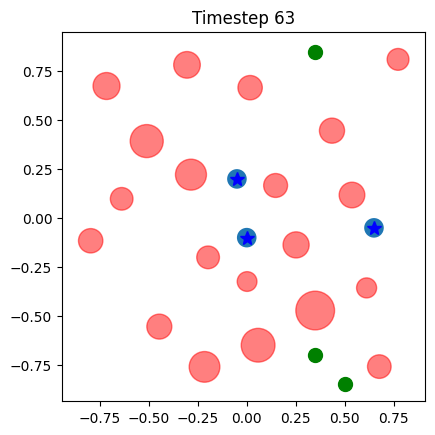

In [210]:
save_video(problem, trajectory, "trajectory_from_langevin.mp4")